$$
\text{灰色预测模型 (Grey Prediction Model)} \\
\text{灰色系统理论是由邓聚龙教授于1982年提出的一门边缘性学科 (interdisciplinary)} \\
\text{灰色系统用颜色的深浅反映信息量的多少, 黑色代表信息量太少, 白色代表信息量充足} \\
\text{处于黑白之间, 或说信息不完全的系统, 称为灰色系统} \\ \quad \\
\text{灰色预测就是对既含有已知信息又含有不确定信息的系统进行预测} \\
\text{对在一定范围内变化的, 与时间有关的灰色过程进行预测}
$$

$$
\text{GM(1,1) 模型 指的是只含有一个变量的一阶微分方程模型} \\
\textbf{如何用 GM(1,1) 模型进行灰色预测?} \\ \quad \\
\text{1. 对原始数据进行累加, 削弱随机性, 获得有规律的离散数据列} \\ \quad \\
\text{2. 建立相应的微分方程模型, 得到离散点处的解} \\ \quad \\
\text{3. 再通过累减求的原始数据的估计值, 从而对原始数据进行预测} \\ \quad \\


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

# 年份 (1995-2004)
years = np.array([1995, 1996, 1997, 1998, 1999, 2000, 2001])
# years = np.array([1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004])

# 排污总量 (对应各年份数值)
pollution = np.array([71.1, 72.4, 72.4, 72.1, 71.4, 72.0, 71.6])
# pollution = np.array([174, 179, 183, 189, 207, 234, 220.5, 256, 270, 285])

# 如果需要进行回归分析，通常会将年份处理为从 0 或 1 开始的序列
x = years  # 相对年份：[0, 1, 2, ..., 9]
y = pollution  # 排污总量
n = len(y)


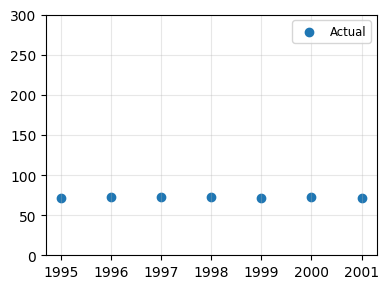

In [2]:
def plot_nicely():
    plt.grid(True, which="both", alpha=0.3)
    plt.legend(fontsize='small')
    plt.tight_layout()


plt.figure(figsize=(4, 3))
plt.scatter(x, y, label='Actual')
plt.ylim(0, 300)
plot_nicely()


$$
\text{级比检验 (Step Ratio Test)} \\
\text{目的是判断原始数据序列是否具有足够的平滑度。如果数据通过了级比检验，说明其符合指数增长规律，适合建立灰色模型；否则，预测精度可能较低。} \\
\text{指数函数 } f(t) = Ce^{at} \text{ 有一个特性: 它在等间隔点上的比值是常数} \\
\lambda(k) = \frac{x^{(0)}(k-1)}{x^{(0)}(k)}, \text{k = 2, 3, ..., n} \\ \quad \\

\text{可容范围} \\
\theta = (e^{-\frac{2}{n+1}}, e^{\frac{2}{n+1}}) \\
\text{如果 } \lambda(k) \text{ 落在可容范围 } \theta \text{ 内，说明数据序列具有足够的平滑度，符合指数增长规律。} \\
\text{否则，说明数据序列不是指数增长的，预测精度可能较低。} \\
\text{需要对原始数列做必要的变换处理，使其落入可容范围。即取适当的常数 C 做平移变换} \\
$$

指数函数的级比检验 [0.86200001 0.86200001 0.86200001 0.86200001]
指数函数的级比范围 [0.7165313105737893 - 1.3956124250860895]


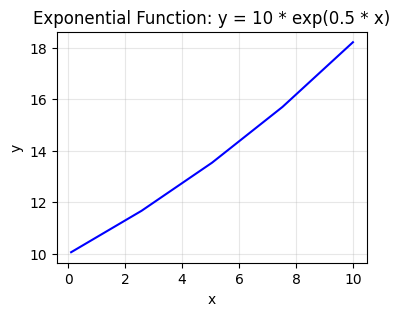

In [3]:
# 指数函数级比检验 (Step Ratio Test)
n = 5
exp_func_x = np.linspace(0.1, 10, n)
exp_func_y = 10 * np.exp(0.06 * exp_func_x)
exp_lambda = exp_func_y[:-1] / exp_func_y[1:]
exp_lambda_L_min = np.exp(-2 / (n + 1))
exp_lambda_L_max = np.exp(2 / (n + 1))

print(f'指数函数的级比检验 {exp_lambda}')
print(f'指数函数的级比范围 [{exp_lambda_L_min} - {exp_lambda_L_max}]')

plt.figure(figsize=(4, 3))
plt.plot(exp_func_x, exp_func_y, 'b')
plt.title("Exponential Function: y = 10 * exp(0.5 * x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)


In [4]:
# 对原始数据做级比检验
y_lambda = y[:-1] / y[1:]
y_min_lambda = np.exp(-2 / (n + 1))
y_max_lambda = np.exp(2 / (n + 1))
print(f'原始数据的级比检验 {y_lambda}')
print(f'原始数据的级比范围 [{y_min_lambda} - {y_max_lambda}]')
if np.all(y_lambda >= y_min_lambda) and np.all(y_lambda <= y_max_lambda):
    print('原始数据通过了级比检验，符合指数增长规律')
else:
    print('原始数据未通过级比检验，不符合指数增长规律')

原始数据的级比检验 [0.9820442  1.         1.00416089 1.00980392 0.99166667 1.00558659]
原始数据的级比范围 [0.7165313105737893 - 1.3956124250860895]
原始数据通过了级比检验，符合指数增长规律


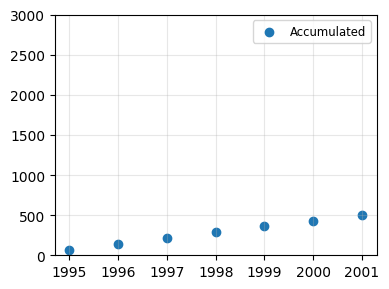

In [5]:
y_accumulate = np.cumsum(y)

plt.figure(figsize=(4, 3))
plt.scatter(x, y_accumulate, label='Accumulated')
plt.ylim(0, 3000)
plot_nicely()


$$
\text{白化方程} \\ \quad \\
\frac{dx}{dt} + ax = b \\
\frac{dx}{dt} \text{ : 代表系统的瞬时变化率} \\
a \text{ : 代表系统的内部阻力或者发展动力} \\
b \text{ : 代表系统外部的驱动力或者环境背景} \\ \quad \\
\text{求解过程: } \\
\frac{dx}{dt} = b - ax \implies \frac{dx}{b - ax} = dt \\
\text{不定积分 (是一个数学表达式, 定积分是一个值或者面积): } \\
\int{\frac{dx}{b - ax}dx} = \int dt \\
\text{令 } u = b - ax \implies \frac{du}{dx} = -a \implies dx = \frac{du}{-a} \\
\text{则 } \int{\frac{1}{u}dx} = \int{\frac{1}{u} \cdot (\frac{du}{-a})}= -\frac{1}{a} \int{\frac{1}{u} du} \\
\text{根据 } \int{\frac{1}{u}du} = \ln{|u|} + C \text{ 得: } \\
-\frac{1}{a} \int{\frac{1}{u} du} = -\frac{1}{a} \ln{|u|} + C = -\frac{1}{a} \ln{|b - ax|} + C_1 \\
-\frac{1}{a} \ln{|b - ax|} + C_1 = dt = \int{dt} = t + C_2 \implies -\frac{1}{a} \ln{|b - ax|} = t + (C_2 - C_1) \\
\text{两边同乘 -a, 得: } \ln{|b - ax|} = -at - aC \\
\text{取指数, 得: } |b - ax| = e^{-at-aC} \implies |b - ax| = e^{-at} \cdot e^{-aC} \\
\implies ax = b - e^{-at} \cdot e^{-aC} \implies x = \frac{b}{a} - \frac{e^{-at}}{a} \cdot \frac{e^{-aC}}{a} \\
\text{令 } C = \frac{e^{-aC}}{a} \implies x = \frac{b}{a} - \frac{e^{-at}}{a} \cdot C \\ \quad \\
\text{用原始数据 } x^{(0)} \text{生成一次累加生成序列: } \\
x^{(1)}(t) = \sum_{i=1}^t x^{(0)}(i) \\
\text{令 } t = 1 \implies x^{(1)}(1) = \frac{b}{a} - C \cdot e^{-a \cdot 1} \implies C = (\frac{b}{a} - x^{(1)}(1))e^{a} \\
\text{代回原式, 得到预测模型: } \\
x^{(1)}(t) = (x^{(1)}(1) - \frac{b}{a})e^{-a(t-1)} + \frac{b}{a} \\
$$

$$
\text{左边的 } x^{(0)}(k) \text{是从时刻 } k-1 \text{ 变到时刻 } k \text{ 的一个过程量(跨越了一个区间)} \\
\text{如果只取 } x^{(1)}(k) \text{(终点) 或者 } x^{(1)}(k-1) \text{(起点), 都会产生明显的偏差} \\
\text{为了更精确地代表这一个区间内的“平均状态”，邓聚龙采用了梯形法则（Trapezoidal Rule）} \\
z^{(1)}(k) = \frac{1}{2} \cdot (x^{(1)}(k) + x^{(1)}(k-1)) \\
$$

In [6]:
print(y_accumulate[1:], y_accumulate[:-1])

[143.5 215.9 288.  359.4 431.4 503. ] [ 71.1 143.5 215.9 288.  359.4 431.4]


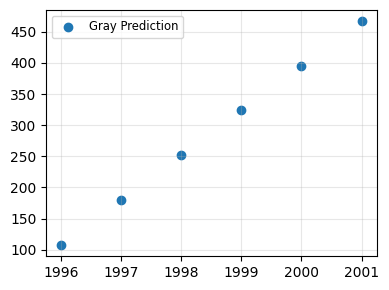

In [7]:
z = 0.5 * (y_accumulate[1:] + y_accumulate[:-1])
plt.figure(figsize=(4, 3))
plt.scatter(x[1:], z, label='Gray Prediction')
plot_nicely()


In [8]:
Y = y[1:].T
X = np.column_stack((np.ones(len(y)-1), -z[:]))
beta = np.linalg.inv(X.T @ X) @ X.T @ Y
print(f"发展系数 a: {beta[1]}")
print(f"灰作用量 b: {beta[0]}")


发展系数 a: 0.002343786478523624
灰作用量 b: 72.6572696036788


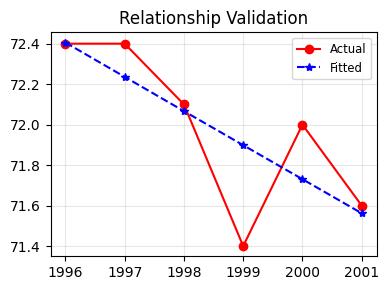

In [9]:
plt.figure(figsize=(4, 3))
plt.plot(x[1:], y[1:], 'ro-', label='Actual')
plt.plot(x[1:], beta[0] + X[:, 1] * beta[1], 'b*--', label='Fitted')
plt.title("Relationship Validation")
plot_nicely()
plt.show()

$$
x^{(1)}(t) = (x^{(1)}(1) - \frac{b}{a})e^{-a(t-1)} + \frac{b}{a} \\
$$

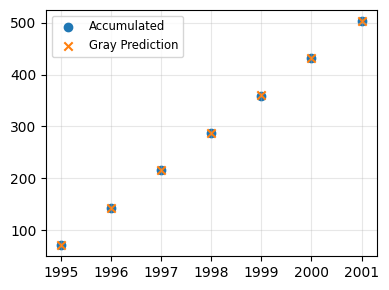

In [10]:
def get_gray_prediction(x, a, b, x0):
    return (x0 - b / a) * np.exp(-a * x) + b / a

# 1. 定义自变量为序号，而不是年份
t_index = np.arange(len(x)) 

# 2. 调用函数时使用 t_index
# beta[1] 是 a, beta[0] 是 b
y_accumulate_pred = get_gray_prediction(t_index, beta[1], beta[0], y_accumulate[0])

# 3. 绘图时，x轴依然可以用年份，但预测值计算必须基于序号
plt.figure(figsize=(4, 3))
plt.scatter(x, y_accumulate, marker='o', label='Accumulated')
plt.scatter(x, y_accumulate_pred, marker='x', label='Gray Prediction')
plot_nicely()

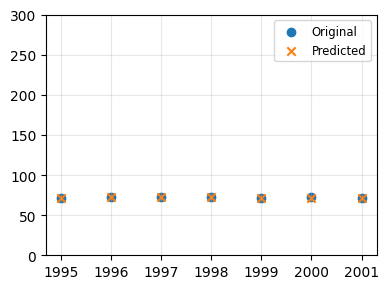

In [11]:
y_pred = np.concatenate([[y[0]], np.diff(y_accumulate_pred)])

plt.figure(figsize=(4, 3))
plt.scatter(x, y, marker='o', label='Original')
plt.scatter(x, y_pred, marker='x', label='Predicted')
plt.ylim(0, 300)
plot_nicely()


$$
\text{对预测值进行检验} \\ \quad \\
\text{1. 残差检验} \\
\epsilon(k) = \frac{x^{(0)}(k) - \hat{x}^{(0)}(k)}{x^{(0)}(k)}, \text{k = 1, 2, ..., n} \\
\text{这里} \hat{x}^{(0)}(1) = x^{(0)}(1) \\
\text{如果 } \epsilon(k) \text{ < 0.2，则可认为达到一般要求。如果 < 0.1，则可认为达到较高要求。} \\ \quad \\
\text{2. 级比偏差值检验} \\
\rho(k) = 1 - (\frac{1-0.5a}{1+0.5a})\lambda(k) \\
\text{如果 } \rho(k) \text{ < 0.2，则可认为达到一般要求。如果 < 0.1，则可认为达到较高要求。} \\ \quad \\
$$

In [12]:
y - y_pred

array([ 0.        , -0.00574144,  0.16376344,  0.0328715 , -0.49841633,
        0.26990088,  0.03782405])

In [13]:
# 1. 残差检验 (使用绝对值)
epsilon_r = np.abs((y - y_pred) / y)
print(f'相对残差: {epsilon_r}')

# 优先级调整：先判断 0.1
if np.all(epsilon_r < 0.1):
    print('残差检验通过，符合较高要求')
elif np.all(epsilon_r < 0.2):
    print('残差检验通过，符合一般要求')
else:
    print('残差检验未通过')

# 2. 级比偏差值检验 (同理)
rho = 1 - (1 - 0.5 * beta[1]) / (1 + 0.5 * beta[1]) * y_lambda
print(f'级比偏差值: {rho}')

if np.all(rho < 0.1):
    print('级比偏差值检验通过，符合较高要求')
elif np.all(rho < 0.2):
    print('级比偏差值检验通过，符合一般要求')
else:
    print('级比偏差值检验未通过')

相对残差: [0.         0.0000793  0.00226193 0.00045592 0.00698062 0.00374862
 0.00052827]
残差检验通过，符合较高要求
级比偏差值: [ 0.02025481  0.00234104 -0.0018101  -0.00743993  0.01065487 -0.00323247]
级比偏差值检验通过，符合较高要求


$$
\text{绝对残差} \epsilon (k) = x^{(0)}(k) - \hat{x}^{(0)}(k) \text{ ，k = 2, 3, ..., n} \\
\text{相对残差} \epsilon_{r} (k) = \frac{|\epsilon (k)|}{x^{(0)}(k)} \times 100 \% \text{ ，k = 2, 3, ..., n} \\
\text{平均相对残差} \hat{\epsilon}_{r} = \frac{1}{n - 1} \sum_{k=2}^n |\epsilon_{r} (k)|
$$